In [1]:
# Import necessary libraries
import pandas as pd
from numpy import arange
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 10 - RF/kc_house_data.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
data = data.drop(['id', 'date', 'yr_renovated', 'zipcode', 'lat', 'long'], axis = 1)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,1800,7503


In [4]:
data.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [5]:
data.shape

(21613, 15)

In [6]:
# Descriptive statistics
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,6210.000000,871200.000000


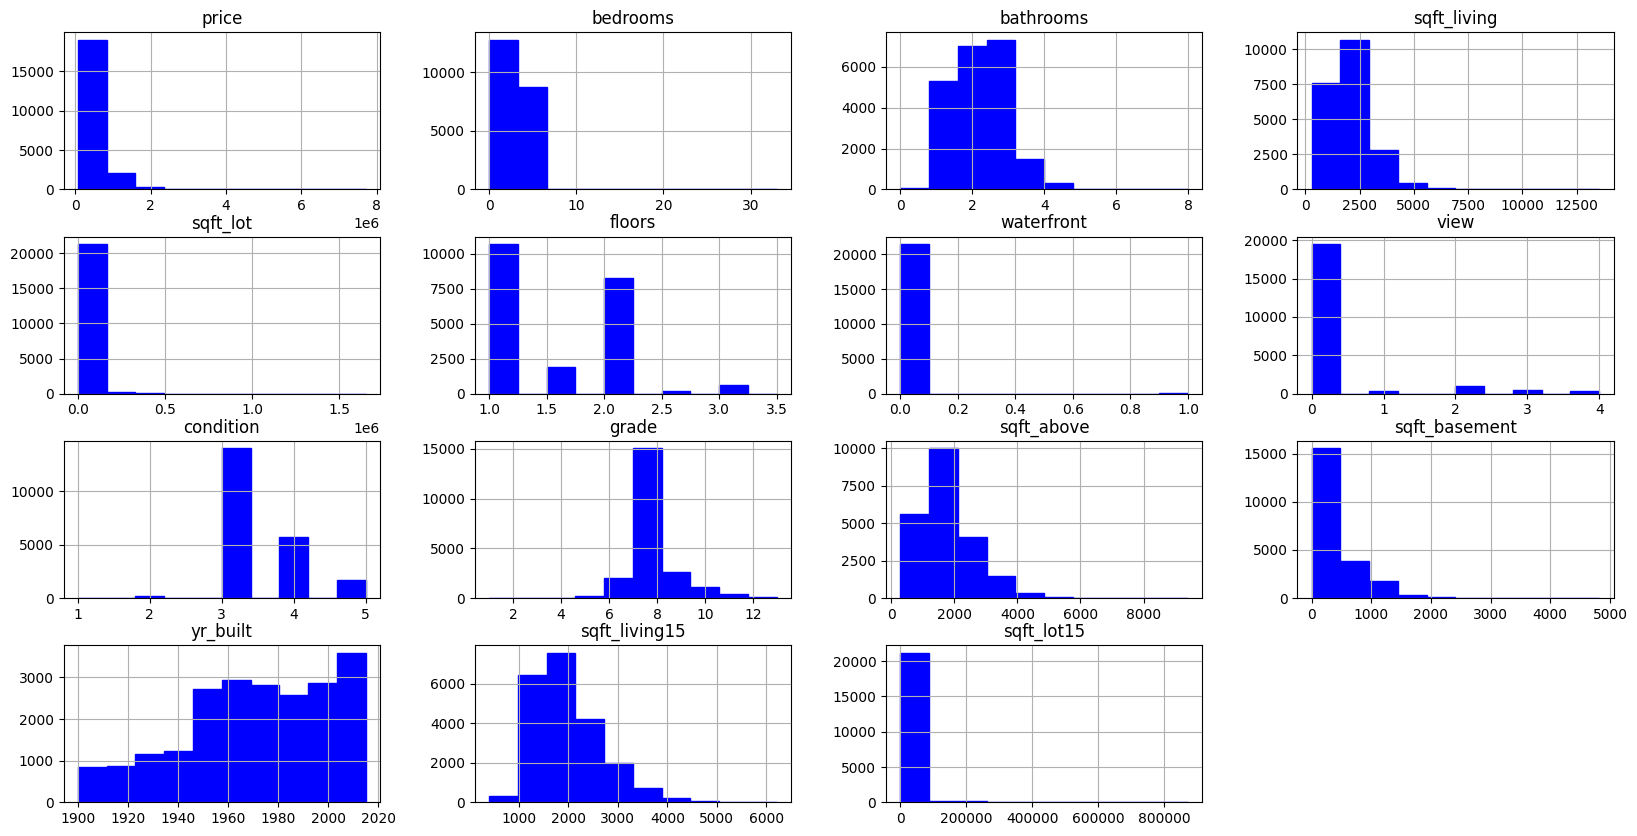

In [7]:
import matplotlib.pyplot as plt
data.hist(figsize = (20,10), edgecolor = "blue", color = "blue")
plt.show()

In [8]:
x = data.drop('price', axis=1)
y = data['price']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [10]:
rf = RandomForestRegressor()
print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


**RF - Base model**

In [11]:
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)


print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))

Mean Squared Error:  45201972863.29108
Mean Absolute Error:  121287.43746925084


**Important Features ~~~~~~~~~~~~~~~~~~**

This is can be obtained using the RF base model. 

This is a very useful output which helps to identify the most significant IVs in predicting the TV.

               Importance
bedrooms         0.007738
bathrooms        0.027897
sqft_living      0.248330
sqft_lot         0.033697
floors           0.005988
waterfront       0.022936
view             0.017074
condition        0.007742
grade            0.380339
sqft_above       0.028193
sqft_basement    0.015520
yr_built         0.099891
sqft_living15    0.065739
sqft_lot15       0.038916



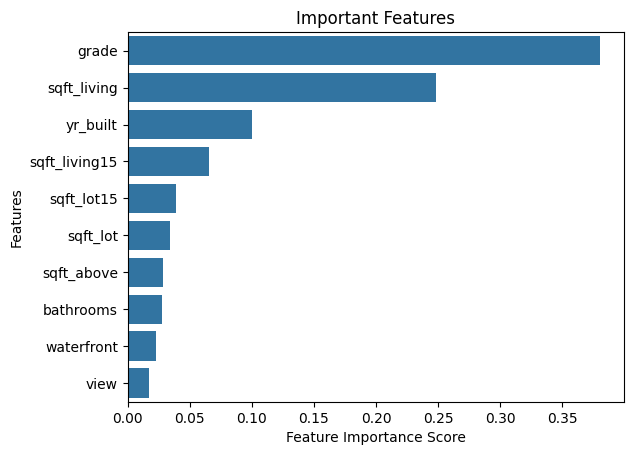

In [12]:
importance = rf.feature_importances_
importance_df = pd.DataFrame(importance, index = x_train.columns, columns = ["Importance"])
print(importance_df)
print()

import matplotlib.pyplot as plt
feature_imp = pd.Series(rf.feature_importances_, index = x_train.columns).sort_values(ascending = False)

# Creating a bar plot, displaying only the top k features
sns.barplot(x = feature_imp[:10], y = feature_imp.index[:10])
# Add labels to your graph
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Important Features")
plt.show()

**RF - RandomizedSearchCV**

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from numpy import arange
from scipy.stats import randint

# Create the parameter grid
parameters = {'criterion': ['squared_error'],
               'n_estimators': randint(100, 200),
               'max_features': ['log2', 'sqrt'],
               'max_depth': randint(2, 10),
               'min_samples_split': randint(2, 5),
               'min_samples_leaf': randint(1, 5),
               'bootstrap': [True, False]
               }

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = parameters, n_iter = 100, cv = 3, scoring = 'neg_mean_squared_error', random_state = 42)

rf_random.fit(x_train, y_train)

print("\nBest Parameters: ", rf_random.best_params_)
print("Best Scores: ", rf_random.best_score_) 

best_rf = rf_random.best_estimator_

y_pred = best_rf.predict(x_test)

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))


Best Parameters:  {'bootstrap': False, 'criterion': 'squared_error', 'max_depth': 9, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 125}
Best Scores:  -33371399248.602283
Mean Squared Error:  46553717937.55611
Mean Absolute Error:  128982.21588229507
